In [1]:
!pip install kagglehub

In [2]:
import os
import random
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import transforms, models
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

from PIL import Image
import kagglehub

In [3]:
path = kagglehub.dataset_download(
    "sabahesaraki/breast-ultrasound-images-dataset"
)

print("Dataset Path:", path)

data_dir = os.path.join(path,"Dataset_BUSI_with_GT")

100%|██████████| 195M/195M [00:01<00:00, 115MB/s]

Extracting files...


Dataset Path: /root/.cache/kagglehub/datasets/sabahesaraki/breast-ultrasound-images-dataset/versions/1


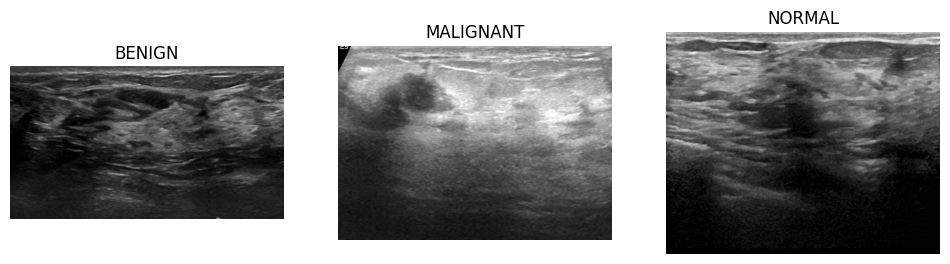

In [4]:
labels = ["benign","malignant","normal"]

plt.figure(figsize=(12,4))

for i,label in enumerate(labels):

    folder = os.path.join(data_dir,label)

    imgs = [f for f in os.listdir(folder) if "_mask" not in f]

    img = random.choice(imgs)

    img_path = os.path.join(folder,img)

    image = Image.open(img_path)

    plt.subplot(1,3,i+1)
    plt.imshow(image,cmap="gray")
    plt.title(label.upper())
    plt.axis("off")

plt.show()

In [5]:
paths = []
targets = []

for label in labels:

    folder = os.path.join(data_dir,label)

    for img in os.listdir(folder):

        if img.endswith(".png") and "_mask" not in img:

            paths.append(os.path.join(folder,img))
            targets.append(label)

df = pd.DataFrame({
    "image":paths,
    "label":targets
})

print("Total Images:",len(df))

Total Images: 780


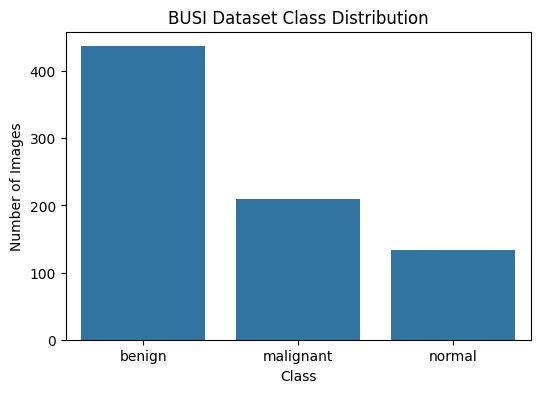

In [6]:
plt.figure(figsize=(6,4))

sns.countplot(x=df["label"])

plt.title("BUSI Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.show()

In [7]:
train_df,temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

val_df,test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

In [8]:
working_dir="/content/busi_dataset"

train_dir=os.path.join(working_dir,"train")
val_dir=os.path.join(working_dir,"val")
test_dir=os.path.join(working_dir,"test")

for d in [train_dir,val_dir,test_dir]:

    for c in labels:

        os.makedirs(os.path.join(d,c),exist_ok=True)

In [9]:
def copy_images(dataframe,target_dir):

    for _,row in dataframe.iterrows():

        src=row["image"]
        label=row["label"]

        dst=os.path.join(target_dir,label,os.path.basename(src))

        shutil.copy(src,dst)

copy_images(train_df,train_dir)
copy_images(val_df,val_dir)
copy_images(test_df,test_dir)

In [10]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [11]:
datasets_dict = {

"train":ImageFolder(train_dir,transform=train_transform),
"val":ImageFolder(val_dir,transform=test_transform),
"test":ImageFolder(test_dir,transform=test_transform)

}

loaders = {

x:DataLoader(datasets_dict[x],batch_size=8,shuffle=True)

for x in ["train","val","test"]

}

dataset_sizes={x:len(datasets_dict[x]) for x in datasets_dict}

class_names=datasets_dict["train"].classes

print("Classes:",class_names)

Classes: ['benign', 'malignant', 'normal']


In [12]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:",device)

Device: cuda


In [13]:
model=models.mobilenet_v2(weights="IMAGENET1K_V1")

model.classifier[1]=nn.Linear(
    model.last_channel,
    len(class_names)
)

model=model.to(device)
criterion=nn.CrossEntropyLoss()

optimizer=optim.Adam(
    model.parameters(),
    lr=0.0001
)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 93.5MB/s]


In [14]:
train_losses=[]

epochs=15

for epoch in range(epochs):

    model.train()

    running_loss=0

    for images,labels in loaders["train"]:

        images=images.to(device)
        labels=labels.to(device)

        optimizer.zero_grad()

        outputs=model(images)

        loss=criterion(outputs,labels)

        loss.backward()

        optimizer.step()

        running_loss+=loss.item()

    epoch_loss=running_loss/len(loaders["train"])

    train_losses.append(epoch_loss)

    print("Epoch",epoch+1,"Loss:",epoch_loss)

Epoch 1 Loss: 0.7798190194627513
Epoch 2 Loss: 0.5317236800556597
Epoch 3 Loss: 0.4479075962866562
Epoch 4 Loss: 0.3585238397337388
Epoch 5 Loss: 0.2800221743359082
Epoch 6 Loss: 0.2258013797033092
Epoch 7 Loss: 0.206430961890821
Epoch 8 Loss: 0.21883095610562875
Epoch 9 Loss: 0.1869721176183742
Epoch 10 Loss: 0.1921616771892793
Epoch 11 Loss: 0.13874151094722142
Epoch 12 Loss: 0.12333988517765766
Epoch 13 Loss: 0.11426820594520457
Epoch 14 Loss: 0.11930388563811994
Epoch 15 Loss: 0.1388627106755756


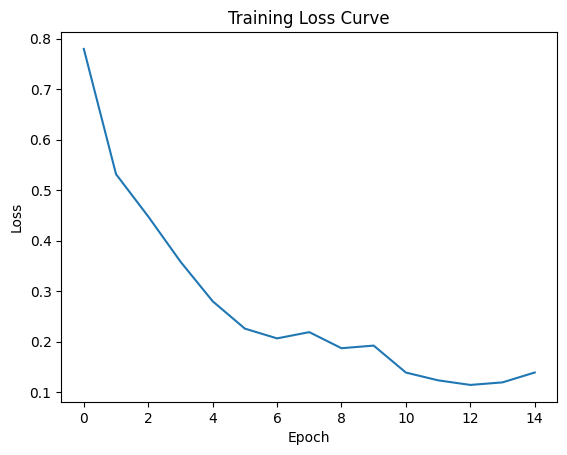

In [15]:
plt.plot(train_losses)

plt.title("Training Loss Curve")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.show()

In [16]:
y_true=[]
y_pred=[]

model.eval()

with torch.no_grad():

    for images,labels in loaders["test"]:

        images=images.to(device)

        outputs=model(images)

        _,preds=torch.max(outputs,1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())

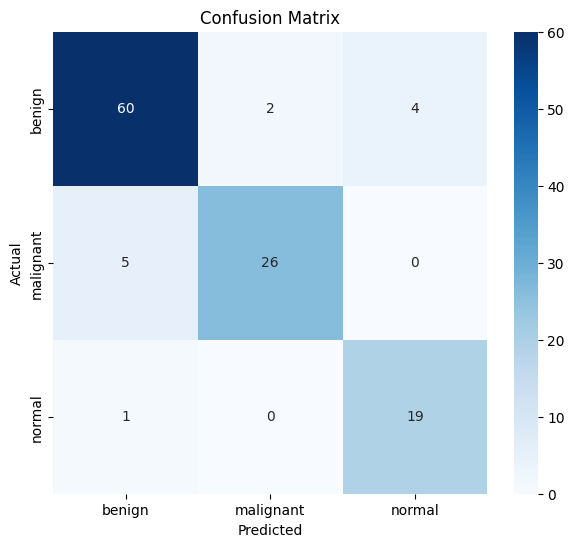

In [17]:
cm=confusion_matrix(y_true,y_pred)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

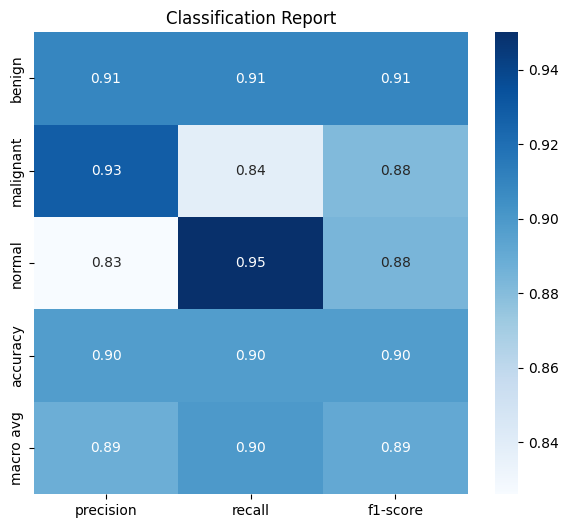

In [18]:
report=classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

report_df=pd.DataFrame(report).transpose()

plt.figure(figsize=(7,6))

sns.heatmap(
    report_df.iloc[:-1,:3],
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Classification Report")

plt.show()

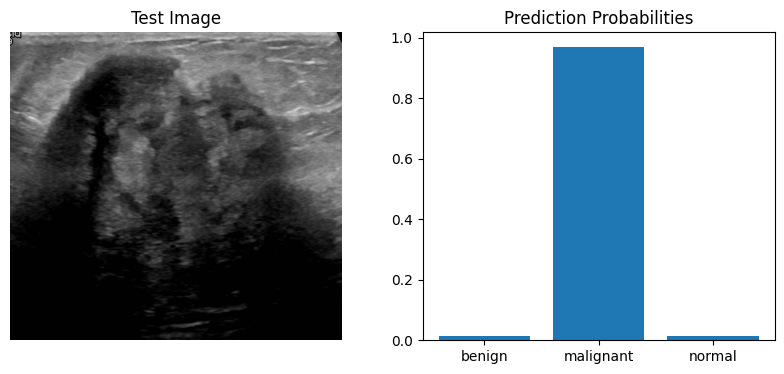

In [22]:
image_path=test_df.iloc[0]["image"]

image=Image.open(image_path)

transform=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

img_tensor=transform(image).unsqueeze(0).to(device)

model.eval()

with torch.no_grad():

    outputs=model(img_tensor)

    probs=torch.softmax(outputs,dim=1).cpu().numpy()[0]

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)

plt.imshow(image,cmap="gray")
plt.title("Test Image")
plt.axis("off")

plt.subplot(1,2,2)

plt.bar(class_names,probs)

plt.title("Prediction Probabilities")

plt.show()